# Gradient Domain Editing

## 📦 Packages

In [3]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

## 🚙 Utilities

In [12]:
def show(i, title: str = "Color Image"):
    t = "gray" if i.ndim == 2 else "color"
    
    if t == "color":
        # color
        plt.imshow(cv2.cvtColor(src=i, code=cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
        plt.show()
    else:
        # gray
        plt.imshow(i, cmap="gray")
        plt.title(title)
        plt.axis("off")
        plt.show()
    

def side2side(i1, i2):
    plt.figure(figsize=(10, 5))
    
    t1 = "gray" if i1.ndim == 2 else "color"
    t2 = "gray" if i2.ndim == 2 else "color"
    
    # color/gray
    plt.subplot(1, 2, 1)
    plt.title(t1)
    if t1 == "gray":
        plt.imshow(X=i1, cmap="gray", vmin=0, vmax=255)
    else:
        plt.imshow(X=cv2.cvtColor(i1, code=cv2.COLOR_BGR2RGB))
    plt.axis("off")
    
    
    # color/gray
    plt.subplot(1, 2, 2)
    plt.title(t2)
    if t2 == "gray":
        plt.imshow(X=i2, cmap="gray", vmin=0, vmax=255)
    else:
        plt.imshow(X=cv2.cvtColor(i2, code=cv2.COLOR_BGR2RGB))
    plt.axis("off")
    

def store(image, file):
    cv2.imwrite(filename=file, img=image)

## 🧑‍💻 Codes

### 🖼️ Images

#### Path

In [4]:
sudoku_path = Path("..") / "data" / "input" / "sudoku.jpg"

#### Images

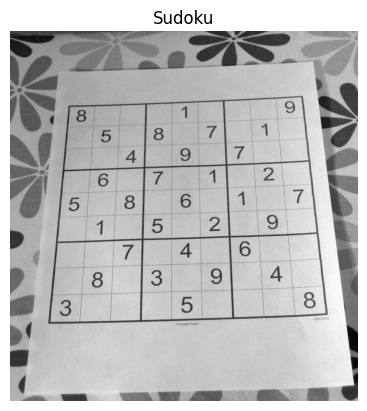

In [17]:
sudoku = cv2.imread(filename=sudoku_path.as_posix())
sudoku = cv2.cvtColor(sudoku, cv2.COLOR_BGR2GRAY)

show(sudoku, title="Sudoku")

### 🤡 Understand Laplacian

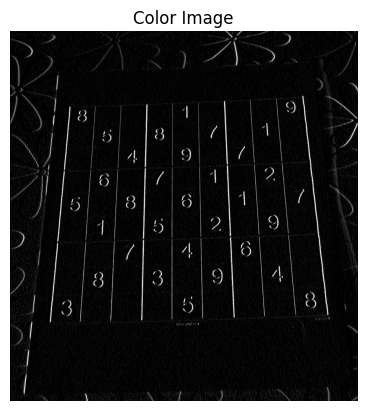

In [25]:
sudoku_sobel_x = cv2.Sobel(sudoku, ddepth=-1, dx=1, dy=0)

show(sudoku_sobel_x)

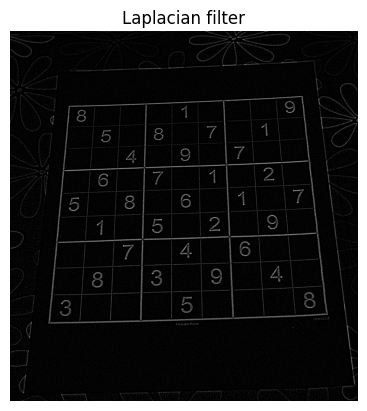

In [54]:
sudoku_gaussion = cv2.GaussianBlur(sudoku, (5, 5), 0)
sudoku_laplacian = cv2.Laplacian(sudoku_gaussion, ddepth=-1)
sudoku_laplacian = cv2.convertScaleAbs(sudoku_laplacian, dst=-1)

show(sudoku_laplacian, title="Laplacian filter")

### 🌀 Seamless cloning